In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 한글 폰트 설정 (Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

### 이상치 시각화

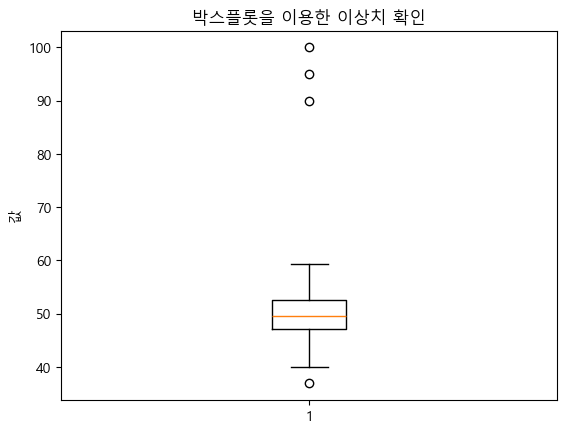

In [13]:
# 재현 가능성을 위한 시드 설정
np.random.seed(42)

# 정상 범위 데이터 생성
# 평균이 50이고 표준편차가 5인 정규 분포에서 100개의 데이터 생성
data = np.random.normal(loc=50, scale=5, size=100)

# 이상치 추가
data = np.append(data, [90, 95, 100])

# 박스플롯 생성
plt.figure()
axes = plt.gca()
axes.boxplot(data)
axes.set_title("박스플롯을 이용한 이상치 확인")
axes.set_ylabel("값")
plt.show()

### 결측치 분포 확인

name      0
dept      1
salary    1
bonus     3
score     2
dtype: int64


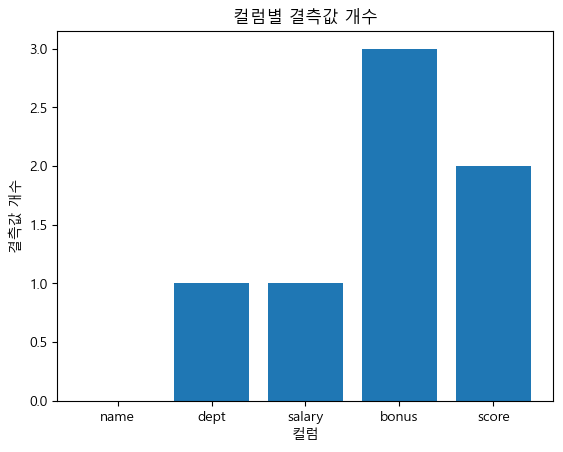

In [14]:
# 샘플 데이터 생성 (일부 결측치 포함)
df = pd.DataFrame({
    "name": ["김철수", "박영희", "이민수", "최지영", "정하나", "오세훈"],
    "dept": ["개발", np.nan, "개발", "영업", "인사", "영업"],
    "salary": [8000, 7500, 6800, 7000, 7700, np.nan],
    "bonus":  [500, np.nan, 400, np.nan, 300, np.nan],
    "score":  [88, 85, 75, np.nan, 90, np.nan],
})

# 컬럼별 결측치 집계
series_missing_count = df.isna().sum()
print(series_missing_count)

# 시각화
plt.figure()
axes = plt.gca()
axes.bar(series_missing_count.index, series_missing_count.values)
axes.set_title("컬럼별 결측값 개수")
axes.set_xlabel("컬럼")
axes.set_ylabel("결측값 개수")
plt.show()

In [15]:
# 결측치 위치(패턴) 시각화: 결측이면 1, 아니면 0
df_missing_map = df.isna().astype(int)
df_missing_map

,name,dept,salary,bonus,score
0,0,0,0,0,0
1,0,1,0,1,0
2,0,0,0,0,0
3,0,0,0,1,1
4,0,0,0,0,0
5,0,0,1,1,1


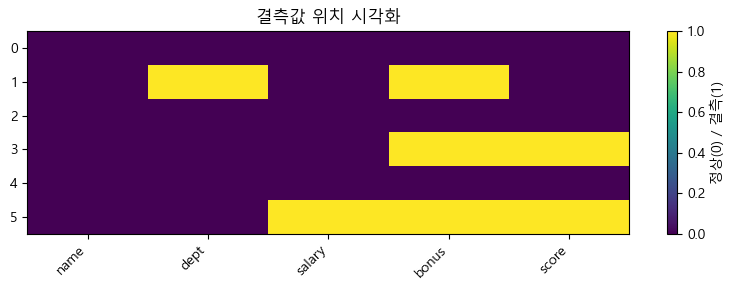

In [ ]:
fig = plt.figure(figsize=(8, 3))

axes = plt.gca()
axes.set_title("결측값 위치 시각화")

# 히트맵 생성: 결측치 위치를 색상으로 표현
# - aspect="auto": 셀의 가로 세로 비율을 자동으로 조정
im = axes.imshow(df_missing_map, aspect="auto")

# X축 눈금 생성
# - range(len(df.columns)): 컬럼 수에 맞는 눈금 위치 생성
axes.set_xticks(range(len(df.columns)))
# - df.columns: 컬럼 이름을 눈금 레이블로 사용
# - rotation=45: 눈금 레이블을 45도 회전하여 가독성 향상
# - ha="right": 텍스트의 끝(오른쪽)이 눈금 위치에 오도록 정렬
axes.set_xticklabels(df.columns, rotation=45, ha="right")

# Y축 눈금 생성
# - range(len(df)): 행 수에 맞는 눈금 생성
axes.set_yticks(range(len(df)))
axes.set_yticklabels(range(len(df)))

# 컬러바 추가: 결측(1)과 정상(0)을 구분하는 색상 범례
fig.colorbar(im, ax=axes, label="정상(0) / 결측(1)")

# 레이아웃 여백 조정
fig.tight_layout()

# 그래프 출력
plt.show()